In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [2]:
import pandas as pd
df = pd.read_csv('C_0_z_v2.csv', sep=',')

In [3]:
z_values = np.array(df['z'])
Co_values = np.array(df['C_0'])

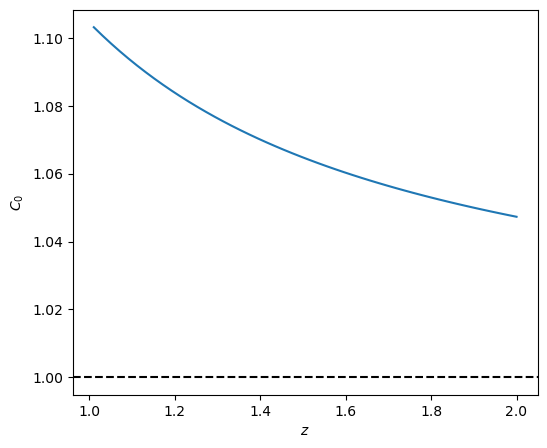

In [4]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[z_values>1], Co_values[z_values>1])
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

The whole idea of the approximation, lies into considering two limiting cases, where $\Delta \ll 1$ and $\Delta \gg 1$, which will create the following integrals:

$$
\int_0^1 \frac{\Delta-1}{\Delta^\beta} f(\Delta, z) d\Delta + f(C_0, z) \int_1^\infty \frac{\Delta-1}{\Delta^\beta} d\Delta = 0
$$

In [6]:
alpha, beta, F0 = 3, 3, 0.1

In [7]:
def f(D, z):
    exponent = D**(-2*alpha)/(2*alpha**2*F0**2/z)
    return np.exp(-exponent)

In [8]:
Delta_array = np.linspace(0.01, 1, 500)

In [9]:
def I1_integral(z):
    I1 = np.trapz((Delta_array-1)*f(Delta_array, z)/Delta_array**beta, Delta_array)
    return I1

In [10]:
def C0(z):
    factor = -18*F0**2/z
    ln_int = np.log(-2*I1_integral(z))
    
    return np.sqrt(factor*ln_int)

In [11]:
C0_approx = np.zeros_like(z_values)

for idx, z in enumerate(z_values):
    C0_approx[idx] = C0(z)

C:\Users\klera\AppData\Local\Temp\ipykernel_13860\3283451516.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(factor*ln_int)


In [12]:
C0_approx

array([       nan, 3.89549416, 3.32145988, 2.9943445 , 2.77507161,
       2.6141494 , 2.48915054, 2.38820587, 2.30434552, 2.23316047,
       2.17170128, 2.11790704, 2.07028647, 2.02772907, 1.98938791,
       1.95460379, 1.92285458, 1.89372047, 1.86685935, 1.84198915,
       1.81887488, 1.79731892, 1.77715365, 1.75823583, 1.7404422 ,
       1.72366599, 1.70781418, 1.69280533, 1.67856772, 1.66503796,
       1.65215973, 1.63988282, 1.62816231, 1.61695785, 1.60623306,
       1.5959551 , 1.58609417, 1.57662321, 1.56751754, 1.55875462,
       1.55031383, 1.54217622, 1.53432439, 1.52674229, 1.51941511,
       1.51232916, 1.50547175, 1.4988311 , 1.49239627, 1.48615707,
       1.48010401, 1.47422823, 1.46852144, 1.46297589, 1.4575843 ,
       1.45233987, 1.44723619, 1.44226723, 1.43742734, 1.43271116,
       1.42811366, 1.42363008, 1.41925593, 1.41498696, 1.41081914,
       1.40674865, 1.40277189, 1.39888541, 1.39508596, 1.39137043,
       1.38773589, 1.38417952, 1.38069866, 1.37729075, 1.37395

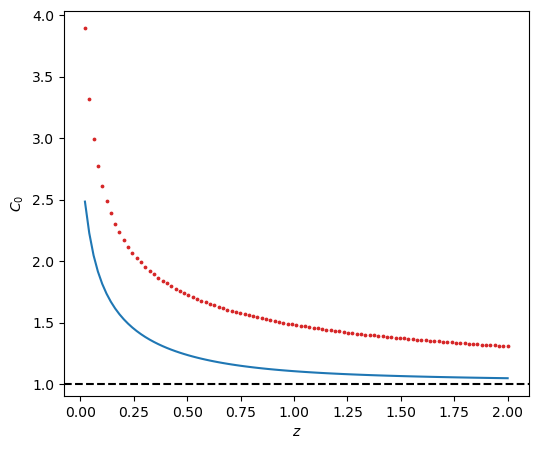

In [14]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], Co_values[1:])
ax.scatter(z_values[1:], C0_approx[1:], c='tab:red', s=3)
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

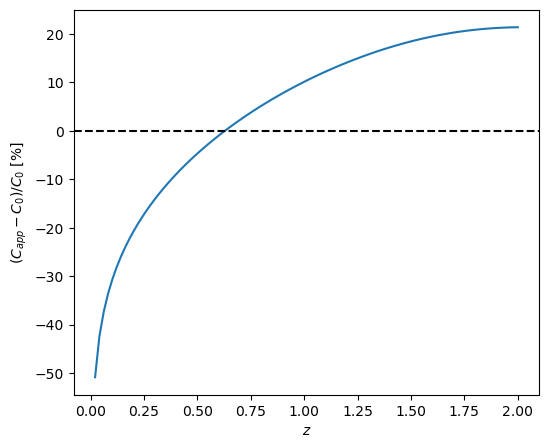

In [13]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], (C0_approx-Co_values[1:])/Co_values[1:]*100)

ax.axhline(y=0, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(C_{app}-C_{0})/C_0$ [%]")

plt.show()

In [14]:
def g(D, Co, z):
    exponent = (D**(-alpha)-Co)**2/(2*alpha**2*F0**2/z)
    return np.exp(-exponent)

In [18]:
def Integral_full(Co, z):
    F_int = np.trapz((Delta_array-1)*g(Delta_array, Co, z)/Delta_array**beta, Delta_array)
    return F_int

In [19]:
Delta_full = np.linspace(0.01, 100, 800)

In [20]:
I_approx = np.zeros_like(z_values[1:])
I_full = np.zeros_like(z_values[1:])

for idx, z in enumerate(z_values[1:]):
    I_full[idx] = Integral_full(Co_values[1:][idx], z)
    I_approx[idx] = Integral_full(C0_approx[idx], z)

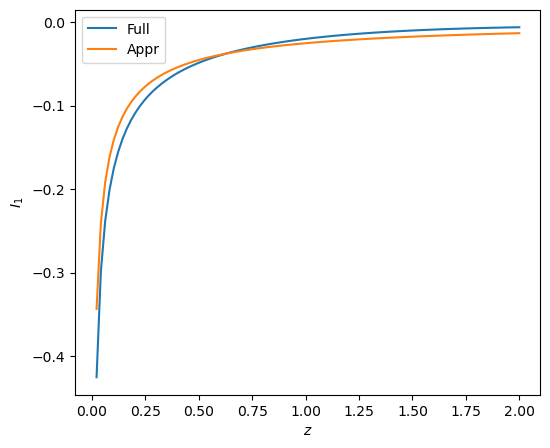

In [21]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], I_full, label='Full')
ax.plot(z_values[1:], I_approx, label='Appr')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$I_1$")

plt.legend()
plt.show()

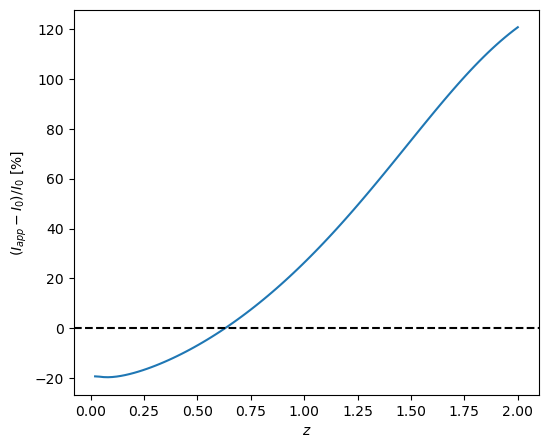

In [22]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], (I_approx-I_full)/I_full*100)

ax.axhline(y=0, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(I_{app}-I_{0})/I_0$ [%]")

plt.show()

-------------------------------------------

$$
\frac{\Delta-1}{\Delta^\beta} \exp \left[ -(\Delta^{-\alpha}-C_0)^2/2\alpha^2\sigma^2 \right]
$$

In [32]:
def pdf_delta_big(D, sigma, C0):
    factor = D**(1-beta)
    exponent = -C0**2/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)


def pdf_delta_small(D, sigma, C0):
    factor = -D**(-beta)
    exponent = -D**(-2*alpha)/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)


def pdf_delta_one(D, sigma, C0):
    factor = D-1
    exponent = -(1-C0)**2/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)

In [33]:
def pdf_delta(D, sigma, C0):
    factor = (D-1)/D**beta
    exponent = -(D**(-alpha)-C0)**2/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)

def pdf_y(y, sigma, C0):
    factor = (1-y**(1/alpha))/(beta*y**(1/beta))
    exponent = -(y-C0)**2/(2*alpha**2*sigma**2)
    
    return factor*np.exp(exponent)

In [61]:
Delta_full = np.linspace(0.001, 100, 5000)

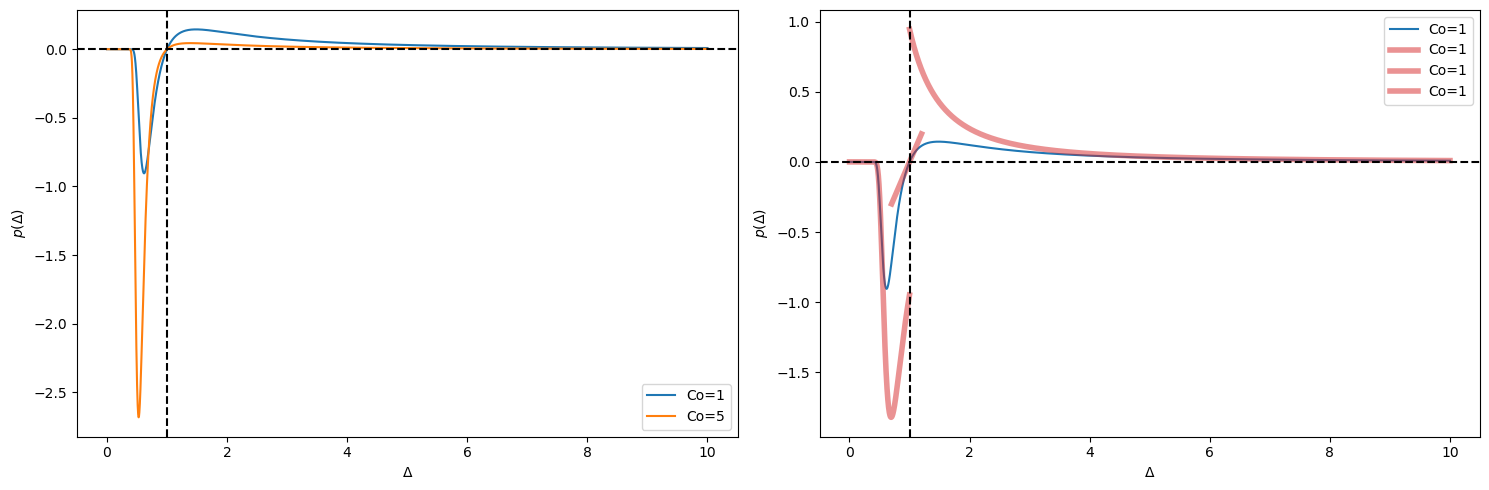

In [35]:
fig= plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(Delta_full, pdf_delta(Delta_full, 1, 1), label='Co=1')
ax1.plot(Delta_full, pdf_delta(Delta_full, 1, 5), label='Co=5')
ax1.axhline(y=0, ls='--', c='black')
ax1.axvline(x=1, ls='--', c='black')
ax1.set_xlabel(r"$\Delta$")
ax1.set_ylabel(r"$p(\Delta)$")
ax1.legend()

ax2.plot(Delta_full, pdf_delta(Delta_full, 1, 1), label='Co=1')
ax2.plot(Delta_full[Delta_full>1], pdf_delta_big(Delta_full[Delta_full>1], 1, 1), label='Co=1', c='tab:red', lw=4, alpha=0.5)
ax2.plot(Delta_full[Delta_full<1], pdf_delta_small(Delta_full[Delta_full<1], 1, 1), label='Co=1', c='tab:red', lw=4, alpha=0.5)
ax2.plot(Delta_full[(Delta_full<1.2)*(Delta_full>0.7)], pdf_delta_one(Delta_full[(Delta_full<1.2)*(Delta_full>0.7)], 1, 1), label='Co=1', c='tab:red', lw=4, alpha=0.5)
ax2.axhline(y=0, ls='--', c='black')
ax2.axvline(x=1, ls='--', c='black')
ax2.set_xlabel(r"$\Delta$")
ax2.set_ylabel(r"$p(\Delta)$")
ax2.legend()

plt.tight_layout()
plt.show()

In [36]:
y_full = np.linspace(0.01, 10, 800)

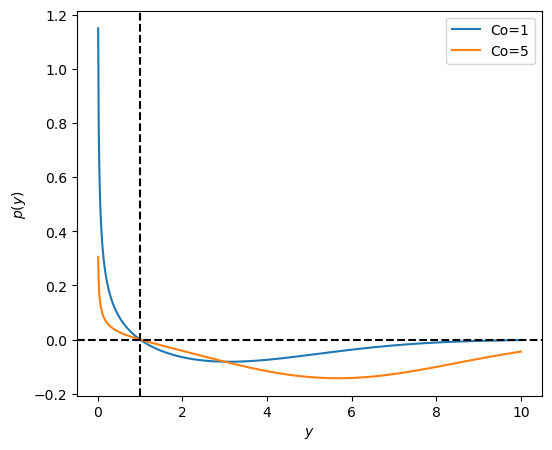

In [37]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(y_full, pdf_y(y_full, 1, 1), label='Co=1')
ax.plot(y_full, pdf_y(y_full, 1, 5), label='Co=5')
ax.axhline(y=0, ls='--', c='black')
ax.axvline(x=1, ls='--', c='black')

ax.set_xlabel(r"$y$")
ax.set_ylabel(r"$p(y)$")

plt.legend()
plt.show()

In [65]:
C0_array = np.logspace(-0.2, 0.4, 150)

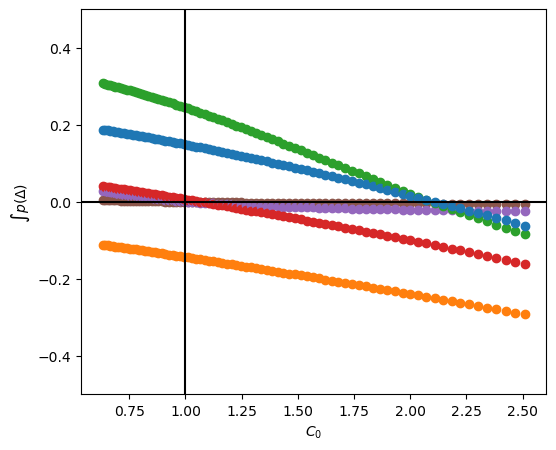

In [39]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

for C0 in C0_array:
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 0.01 , C0), Delta_full), c='tab:brown')    
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 0.05 , C0), Delta_full), c='tab:purple')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 0.5 , C0), Delta_full), c='tab:green')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 1.0 , C0), Delta_full), c='tab:blue')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 1.5 , C0), Delta_full), c='tab:red')
    ax.scatter(C0, np.trapz(pdf_delta(Delta_full, 2.0 , C0), Delta_full), c='tab:orange')    


ax.axhline(y=0, ls='-', c='black')
ax.axvline(x=1, ls='-', c='black')

ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\int p(\Delta)$")

ax.set_ylim(-0.5, 0.5)

plt.show()    

In [40]:
integral = np.ones_like(C0_array)

for idx, C0 in enumerate(C0_array):
    integral[idx] = np.trapz(pdf_delta(Delta_full, 0.2, C0), Delta_full)

In [41]:
integral

array([ 0.26555846,  0.26116483,  0.25666484,  0.25205873,  0.247347  ,
        0.24253035,  0.23760974,  0.23258639,  0.22746177,  0.22223764,
        0.21691605,  0.21149935,  0.2059902 ,  0.20039156,  0.19470675,
        0.1889394 ,  0.18309349,  0.17717332,  0.17118356,  0.16512919,
        0.15901557,  0.15284837,  0.14663359,  0.14037756,  0.1340869 ,
        0.12776854,  0.12142968,  0.11507777,  0.1087205 ,  0.10236576,
        0.0960216 ,  0.08969624,  0.08339797,  0.07713519,  0.07091628,
        0.06474963,  0.05864356,  0.05260629,  0.04664587,  0.04077014,
        0.0349867 ,  0.02930281,  0.02372542,  0.01826105,  0.01291577,
        0.00769516,  0.0026043 , -0.00235232, -0.0071708 , -0.01184786,
       -0.01638084, -0.02076776, -0.02500727, -0.02909869, -0.03304198,
       -0.03683776, -0.04048722, -0.04399217, -0.04735495, -0.05057843,
       -0.05366592, -0.05662116, -0.05944825, -0.0621516 , -0.06473585,
       -0.06720584, -0.06956654, -0.07182301, -0.07398031, -0.07

In [42]:
np.sign(integral)

array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1.])

In [43]:
np.argwhere(np.diff(np.sign(integral))<0)[0][0]

46

In [44]:
np.argwhere(np.min(np.abs(integral))==np.abs(integral))[0][0]

47

In [45]:
C0_array[np.argwhere(np.min(np.abs(integral))==np.abs(integral))[0][0]]

1.43536391973092

In [46]:
def find_C0(Delta_array, C0_array, sigma):
    integral = np.ones_like(C0_array)

    for idx, C0 in enumerate(C0_array):
        integral[idx] = np.trapz(pdf_delta(Delta_array, sigma, C0), Delta_array)
        
    C0_norm = C0_array[np.argwhere(np.min(np.abs(integral))==np.abs(integral))[0][0]]
    
    # C0_norm = C0_array[np.argwhere(np.diff(np.sign(integral))<0)[0][0]]
    
    return C0_norm

In [47]:
find_C0(Delta_full, C0_array, 0.2)

1.43536391973092

In [48]:
sigma_values = np.array([0.5, 0.8, 1.0, 1.2, 1.5])
C0_values = np.zeros_like(sigma_values)

for idx, sig in enumerate(sigma_values):
    C0_values[idx] = find_C0(Delta_full, C0_array, sig)

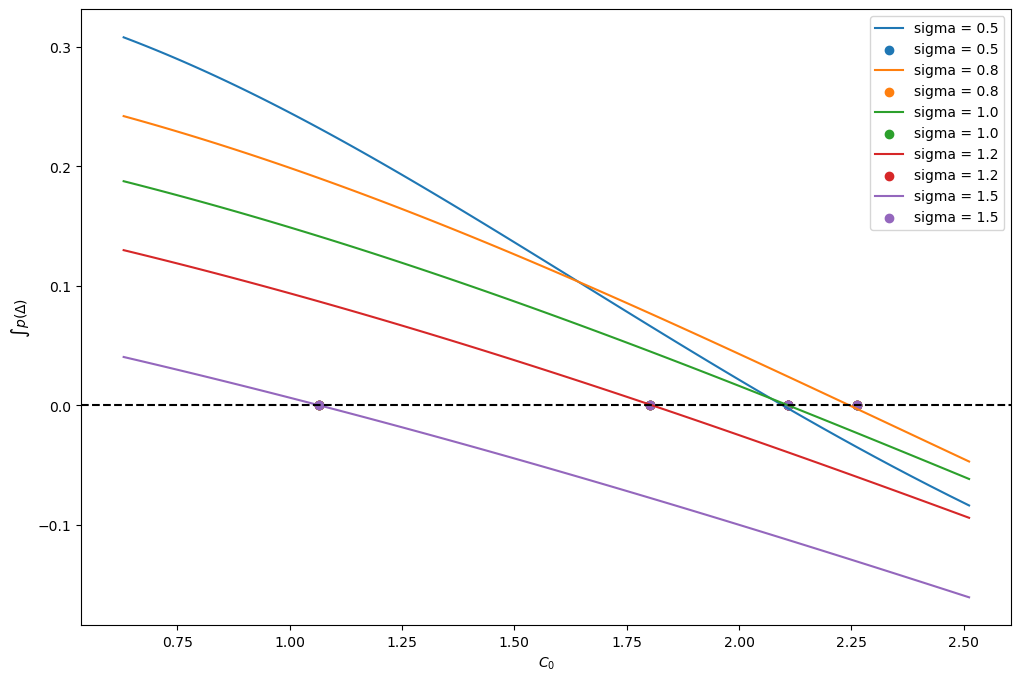

In [49]:
fig= plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)

for sig in sigma_values:
    integral_val = np.ones_like(C0_array)
    for idx, C0 in enumerate(C0_array):
        integral_val[idx] = np.trapz(pdf_delta(Delta_full, sig , C0), Delta_full)
        
    ax.plot(C0_array, integral_val, label=f'sigma = {sig}')
    
    ax.scatter(C0_values, np.zeros_like(sigma_values), label=f'sigma = {sig}')    

ax.axhline(y=0, ls='--', c='black')
# ax.axvline(x=1, ls='--', c='black')

ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\int p(\Delta)$")

ax.legend(fontsize=10)
# ax.set_ylim(-0.1, 0.3)


plt.show()    

In [50]:
sigma_values, C0_array

(array([0.5, 0.8, 1. , 1.2, 1.5]),
 array([0.63095734, 0.64208857, 0.65341616, 0.6649436 , 0.6766744 ,
        0.68861215, 0.70076051, 0.71312319, 0.72570396, 0.73850668,
        0.75153527, 0.7647937 , 0.77828604, 0.79201641, 0.805989  ,
        0.82020809, 0.83467804, 0.84940326, 0.86438826, 0.87963763,
        0.89515601, 0.91094818, 0.92701894, 0.94337322, 0.96001602,
        0.97695243, 0.99418763, 1.01172689, 1.02957557, 1.04773913,
        1.06622313, 1.08503323, 1.10417516, 1.1236548 , 1.14347809,
        1.1636511 , 1.18418   , 1.20507106, 1.22633068, 1.24796536,
        1.26998172, 1.29238648, 1.3151865 , 1.33838875, 1.36200034,
        1.38602847, 1.41048051, 1.43536392, 1.46068632, 1.48645545,
        1.5126792 , 1.53936558, 1.56652276, 1.59415904, 1.62228287,
        1.65090286, 1.68002775, 1.70966646, 1.73982805, 1.77052175,
        1.80175694, 1.83354317, 1.86589017, 1.89880782, 1.93230621,
        1.96639557, 2.00108632, 2.03638908, 2.07231465, 2.108874  ,
        2.146

In [51]:
C0_values

array([2.108874  , 2.26167595, 2.108874  , 1.80175694, 1.06622313])

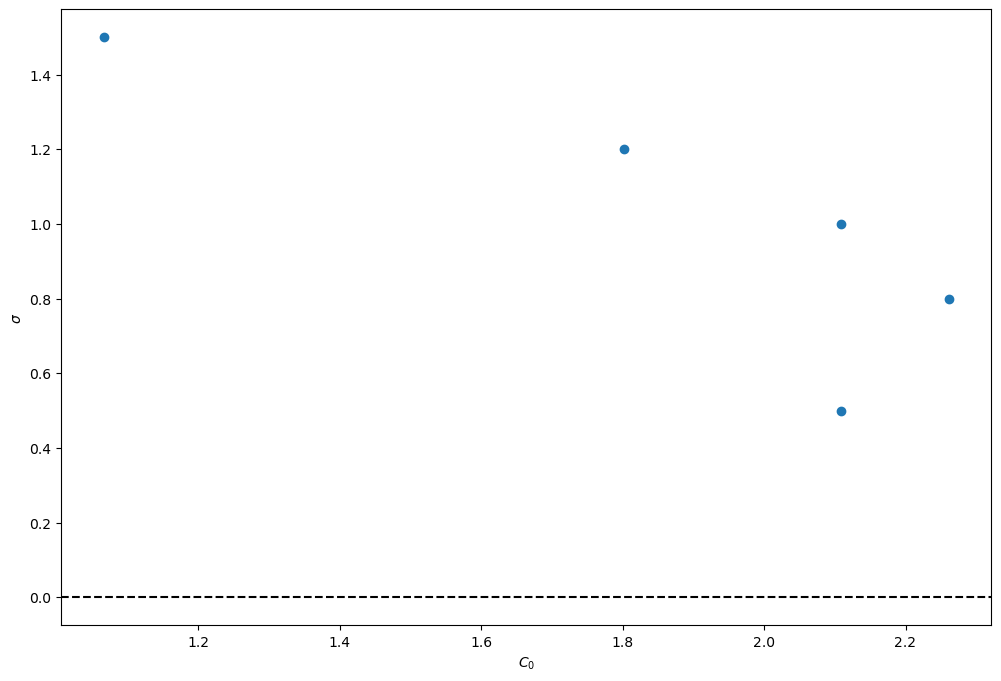

In [52]:
fig= plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)

   
ax.scatter(C0_values, sigma_values)    

ax.axhline(y=0, ls='--', c='black')
# ax.axvline(x=1, ls='--', c='black')

ax.set_xlabel(r"$C_0$")
ax.set_ylabel(r"$\sigma$")

plt.show() 

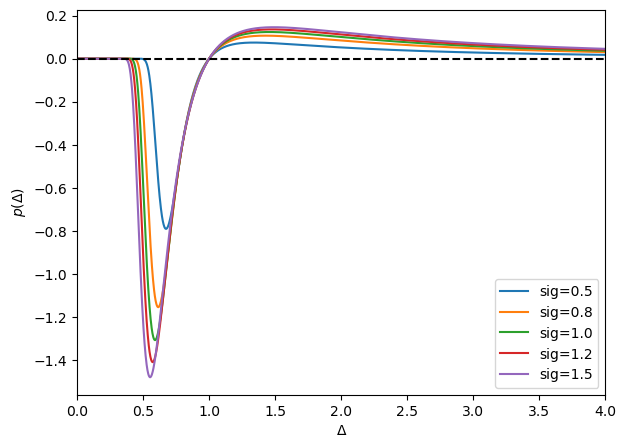

In [53]:
fig= plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1, 2, 1)

for idx, sig in enumerate(sigma_values):
    ax1.plot(Delta_full, pdf_delta(Delta_full, sig, C0_values[idx]), label=f'sig={sig}')

ax1.axhline(y=0, ls='--', c='black')
ax1.set_xlabel(r"$\Delta$")
ax1.set_ylabel(r"$p(\Delta)$")
ax1.legend()

ax1.set_xlim(0, 4)

plt.show()

In [54]:
def find_C0_from_Fz(Delta_array, C0_array, F, z):
    sigma = F/np.sqrt(z)
    C0 = find_C0(Delta_array, C0_array, sigma)
    
    return C0

In [66]:
Fs = np.linspace(0.01, 0.5,10)
results = {}

for F in Fs:
    C_0 = find_C0_from_Fz(Delta_full, C0_array, F=F, z=0.2)
    print(f"For F = {F}: C_0 = {C_0}")

For F = 0.01: C_0 = 1.0030954994397723
For F = 0.06444444444444444: C_0 = 1.2415371850064116
For F = 0.11888888888888888: C_0 = 1.6703935022707759
For F = 0.17333333333333334: C_0 = 2.010739014720136
For F = 0.22777777777777777: C_0 = 2.2473869378419136
For F = 0.2822222222222222: C_0 = 2.4204305032445634
For F = 0.33666666666666667: C_0 = 2.51188643150958
For F = 0.3911111111111111: C_0 = 2.51188643150958
For F = 0.44555555555555554: C_0 = 2.51188643150958
For F = 0.5: C_0 = 2.4204305032445634


In [67]:
C0_quick = np.zeros_like(z_values)

for idx, z in enumerate(z_values):
    C0_quick[idx] = find_C0_from_Fz(Delta_full, C0_array, 0.1, z)

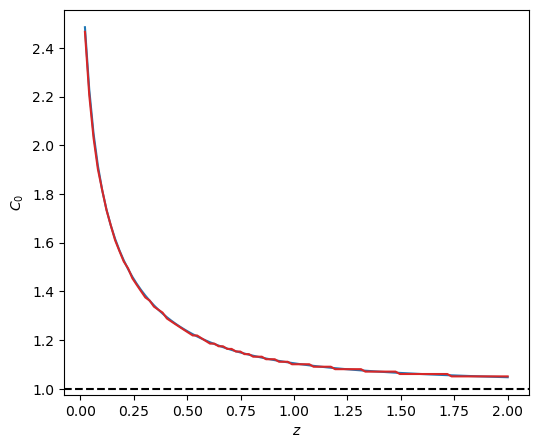

In [68]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], Co_values[1:])
# ax.scatter(z_values[z_values>0.04], C0_quick[z_values>0.04], c='tab:red', s=3)
ax.plot(z_values[1:], C0_quick[1:], c='tab:red')
# ax.scatter(z_values[z_values>0.04], C0_approx[z_values>0.04], c='tab:green', s=3, marker='+')
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

In [69]:
import timeit

In [70]:
print("\n Timing for Marios:")
%timeit find_C0_from_Fz(Delta_full, C0_array, 0.1, 1)


 Timing for Marios:
85 ms ± 5.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
